In [1]:
import missingno as msno
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as  sns

In [2]:
data = pd.read_csv(r"Melbourne_housing.csv")

# **Section** : EDA

take a look about our data

In [3]:
data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Date',
       'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longtitude',
       'Regionname', 'Propertycount', 'ParkingArea', 'Price'],
      dtype='object')

In [4]:
for col in data.columns: 
    print(f"""--- {col} Feature --- \n{data[col].describe()}
---------------------------""")

--- Suburb Feature --- 
count         34857
unique          351
top       Reservoir
freq            844
Name: Suburb, dtype: object
---------------------------
--- Address Feature --- 
count            34857
unique           34009
top       5 Charles St
freq                 6
Name: Address, dtype: object
---------------------------
--- Rooms Feature --- 
count    34857.000000
mean         3.031012
std          0.969933
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         16.000000
Name: Rooms, dtype: float64
---------------------------
--- Type Feature --- 
count     34857
unique        3
top           h
freq      23980
Name: Type, dtype: object
---------------------------
--- Method Feature --- 
count     34857
unique        9
top           S
freq      19744
Name: Method, dtype: object
---------------------------
--- SellerG Feature --- 
count      34857
unique       388
top       Jellis
freq        3359
Name: SellerG, dtype: object
-----

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

In [6]:
print(f"the number of duplicated values : {data.duplicated().sum()}")

the number of duplicated values : 0


In [7]:
data.head()

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


In [8]:
for col in data.select_dtypes(include="object").columns: 
    print(f"varity in --- {col} ---> { data[col].value_counts().shape[0] }")

varity in --- Suburb ---> 351
varity in --- Address ---> 34009
varity in --- Type ---> 3
varity in --- Method ---> 9
varity in --- SellerG ---> 388
varity in --- Date ---> 78
varity in --- BuildingArea ---> 994
varity in --- CouncilArea ---> 33
varity in --- Regionname ---> 8
varity in --- ParkingArea ---> 8


<Axes: >

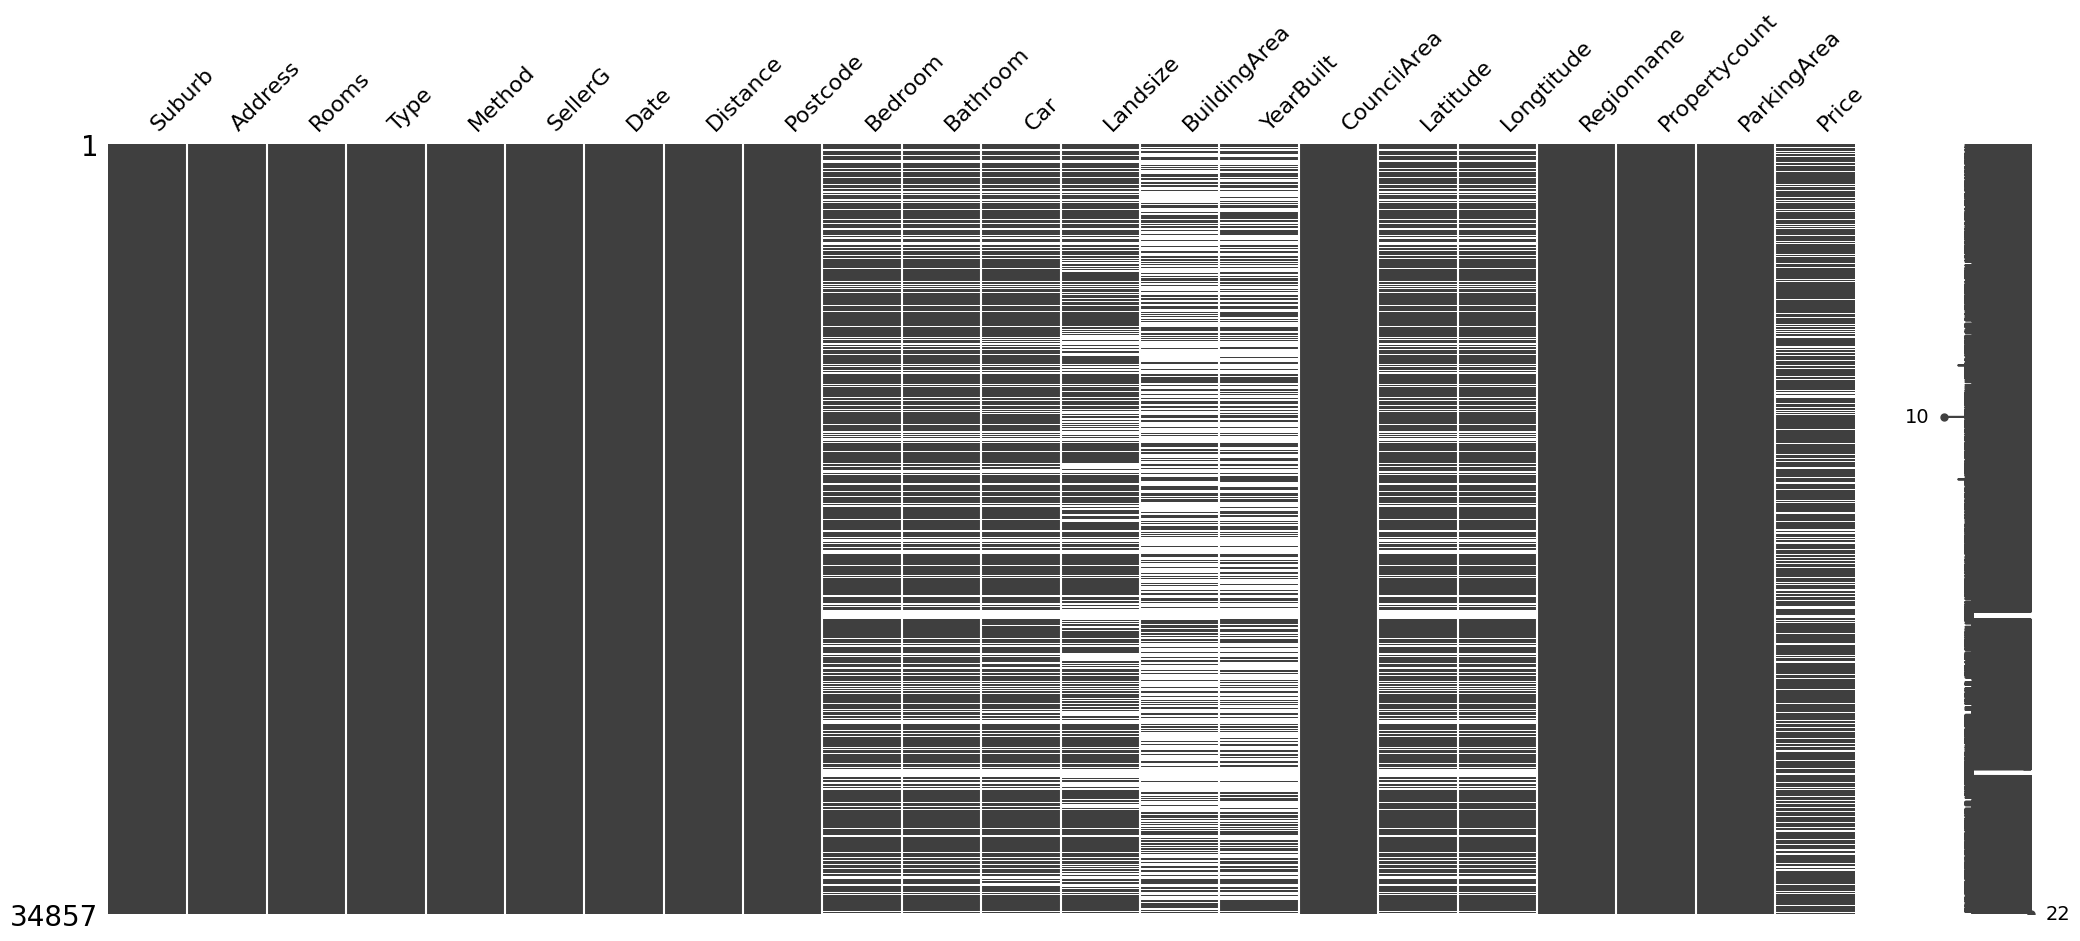

In [9]:
# see the null in visu
msno.matrix(data)

# Notes
* there is some columns need rename ✔️
* check the null and inf and replace it ✔️
* need to convert the data columns from object to dateTime ✔️



### rename the columns 


In [10]:
type_col = {
    'h': "House",
    'u':"Unit",
    't' : "Townhouse"
}
data['Type'].replace(to_replace=type_col , inplace=True )
data['Type'].head(3)

0        House
1    Townhouse
2        House
Name: Type, dtype: object

In [11]:
data['Method'].value_counts()

Method
S     19744
SP     5095
PI     4850
VB     3108
SN     1317
PN      308
SA      226
W       173
SS       36
Name: count, dtype: int64

In [12]:
method_dict = {
    "S": "Sold",
    "SP": "Sold Prior",
    "PI": "Passed In",
    "VB": "Vendor Bid",
    "SN": "Sold Not Disclosed",
    "PN": "Sold Prior Not Disclosed",
    "SA": "Sold After Auction",
    "W": "Withdrawn",
    "SS": "Sold After Auction Price Not Disclosed"
}

data['Method'].replace(to_replace=method_dict , inplace=True )
data['Method'].head(3)

0    Sold After Auction Price Not Disclosed
1                                 Passed In
2                                      Sold
Name: Method, dtype: object

### Missing Values in our data

In [13]:
### Missing Values in our data
(data.isna().sum()).sort_values(ascending=False)

BuildingArea     21097
YearBuilt        19306
Landsize         11810
Car               8728
Bathroom          8226
Bedroom           8217
Latitude          7976
Longtitude        7976
Price             7610
CouncilArea          3
Propertycount        3
Distance             1
Postcode             1
Suburb               0
SellerG              0
Method               0
Type                 0
Rooms                0
Address              0
Date                 0
Regionname           0
ParkingArea          0
dtype: int64

In [14]:
#drop null for small values
drop_null_list = ['CouncilArea','Propertycount' ,'Distance', 'Postcode'] 
data.dropna(subset = drop_null_list,inplace = True)

In [15]:
# fill with median the longtude and latitude
data['Longtitude'] = data['Longtitude'].fillna(data['Longtitude'].median())
data['Latitude'] = data['Latitude'].fillna(data['Latitude'].median())

In [16]:
data["BuildingArea"] = pd.to_numeric(data["BuildingArea"], errors='coerce')
data["BuildingArea"].replace([np.inf , -np.inf] , np.nan ,inplace=True)

# create new features

In [17]:
# use this columns 'Bedroom', 'Bathroom', 'Car', 'Landsize','BuildingArea', 'YearBuilt' 
# and check if missing or not if not create new col to class ot as is house or not
cols_to_check = ['Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']

data['property_type'] = data[cols_to_check].isnull().all(axis=1)

data['property_type'] = data['property_type'].replace({
    True: 'Land',
    False: 'Building'
})

In [18]:
data['property_type'].value_counts()

property_type
Building    26647
Land         8207
Name: count, dtype: int64

In [19]:
data['Price'] = data['Price'].fillna(
    data.groupby('property_type')['Price'].transform('mean')
)

In [20]:
# create columns for year and month from datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Quarter'] = data['Date'].dt.quarter

In [153]:
# create a bulid age
data['Build Age'] = 2026 - data['YearBuilt']

In [ ]:
# cheak the values for build age
data['Build Age'].value_counts().sort_values(ascending=False)

Build Age
56.0     1490
66.0     1260
76.0     1089
46.0      726
126.0     606
         ... 
830.0       1
143.0       1
84.0        1
150.0       1
206.0       1
Name: count, Length: 160, dtype: int64

In [160]:
# split bulid ages to classes
labels = ['Very New', 'New', 'Medium', 'Old', 'Very Old']
data['Age Group'] = pd.cut(data['Build Age'],labels=labels , bins=[0 , 50 , 100 , 150 , 200 ,1000]) 

In [163]:
age_vs_price = data.groupby('Age Group')['Price'].sum().sort_values(ascending=False)/10000

In [165]:
# find top 5 seller
top_5_seller_price = data.groupby('SellerG')['Price'].mean().sort_values(ascending=False)/1000000

In [131]:
top_5_seller_count = data.groupby('SellerG')['Price'].value_counts().sort_values(ascending=False)/1000

In [145]:
# find top region with price
top_region_price = data.groupby('Regionname')['Price'].mean().sort_values(ascending=False)/1000000

In [126]:
# find best quarter for selling propety
best_quarter = data.groupby('Quarter')['Price'].sum().sort_values(ascending=False)/100000

In [127]:
# find best year for selling propety
best_year = data.groupby('Year')['Price'].sum().sort_values(ascending=False)/100000

In [128]:
# find best Month for selling propety
best_month = data.groupby('Month')['Price'].sum().sort_values(ascending=False)/100000

In [69]:
# find type with price
type_price = data.groupby('Type')['Price'].mean().sort_values(ascending=False)

## *Visulization*

<Axes: xlabel='Latitude', ylabel='Longtitude'>

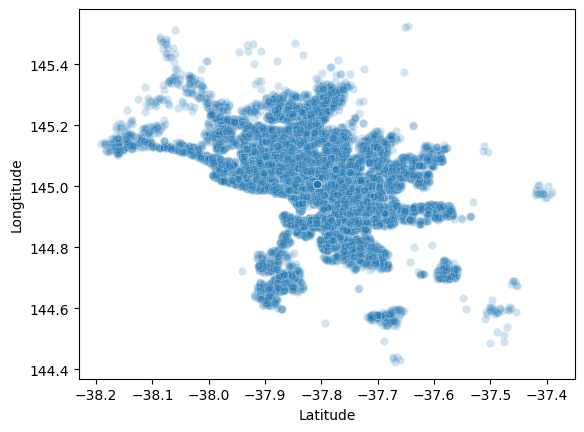

In [ ]:
# diplay the dis for data 
sns.scatterplot(data = data  , x="Latitude", y="Longtitude" , alpha=0.2)

### The Type vs Price and Count

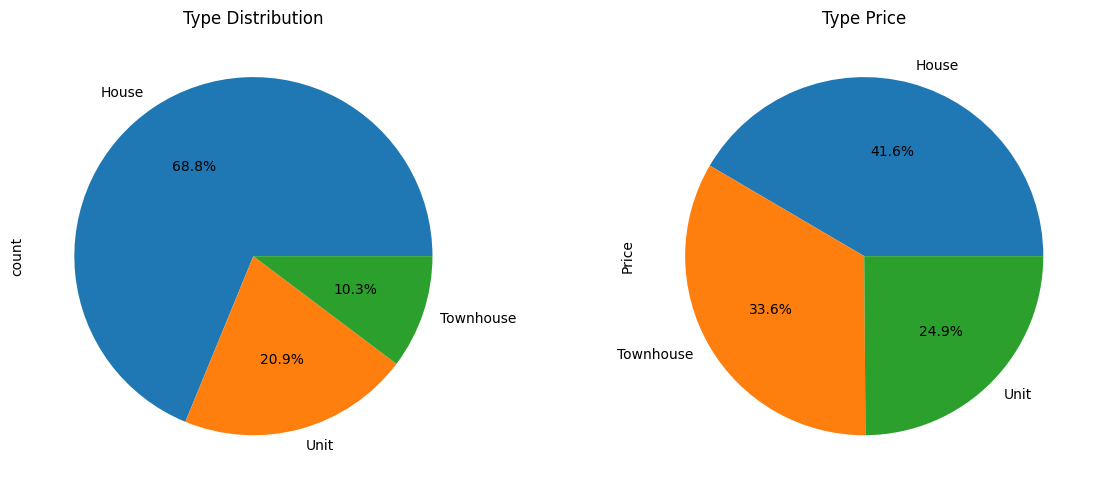

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


data['Type'].value_counts().plot.pie(ax=ax[0], autopct='%1.1f%%')
ax[0].set_title("Type Distribution")


type_price.plot.pie(ax=ax[1], autopct='%1.1f%%')
ax[1].set_title("Type Price")

plt.tight_layout()
plt.show()

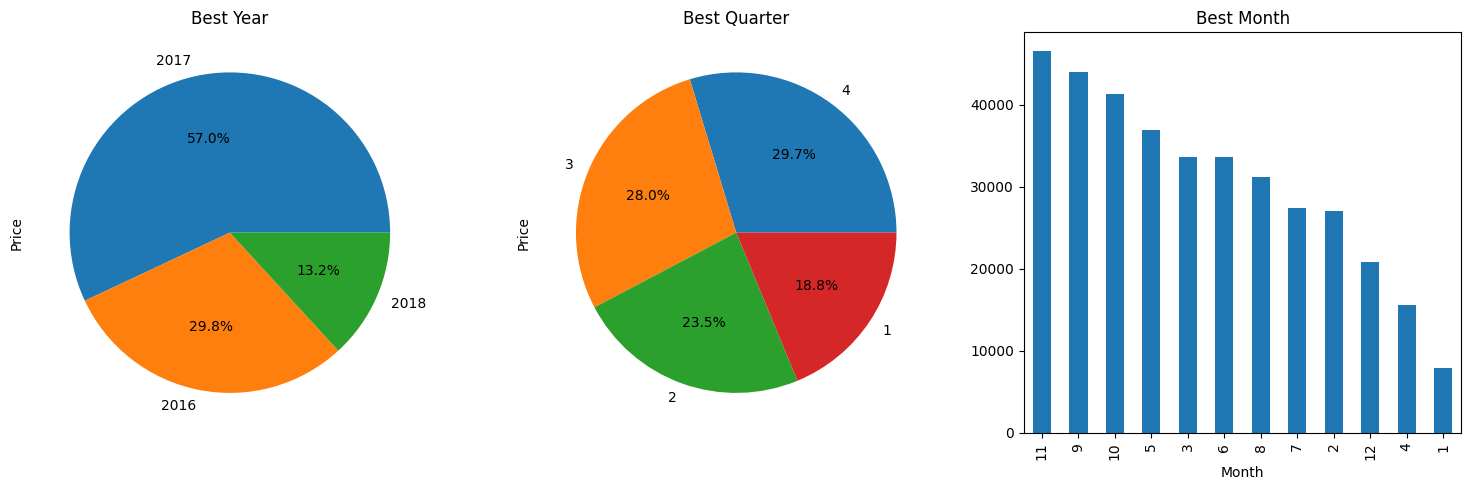

In [129]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Year → Pie

best_year.plot.pie(ax=ax[0], autopct='%1.1f%%')
ax[0].set_title("Best Year")

# Quarter → Pie
best_quarter.plot.pie(ax=ax[1], autopct='%1.1f%%')
ax[1].set_title("Best Quarter")

# Month → Bar
best_month.plot.bar(ax=ax[2])
ax[2].set_title("Best Month")

plt.tight_layout()
plt.show()

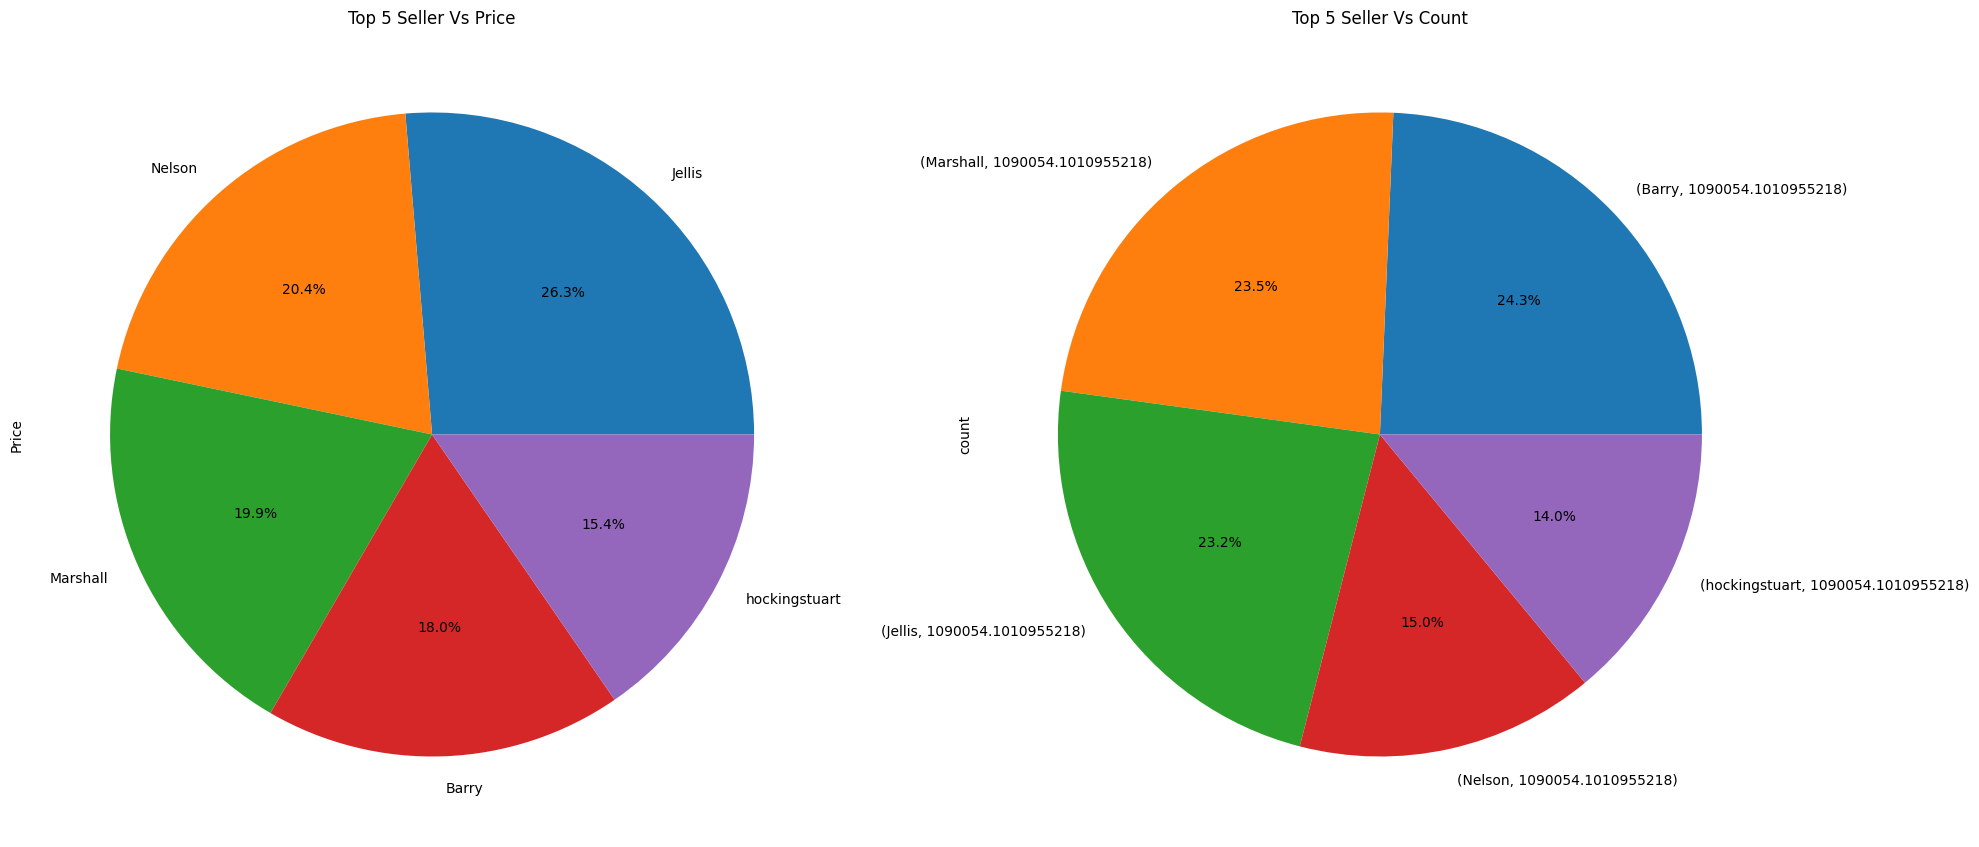

In [133]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].set_title("Top 5 Seller Vs Price")
top_5_seller_price.head(5).plot.pie(ax=ax[0] , autopct='%1.1f%%')

ax[1].set_title("Top 5 Seller Vs Count")
top_5_seller_count.head(5).plot.pie(ax=ax[1] , autopct='%1.1f%%' )

plt.tight_layout()
plt.show()

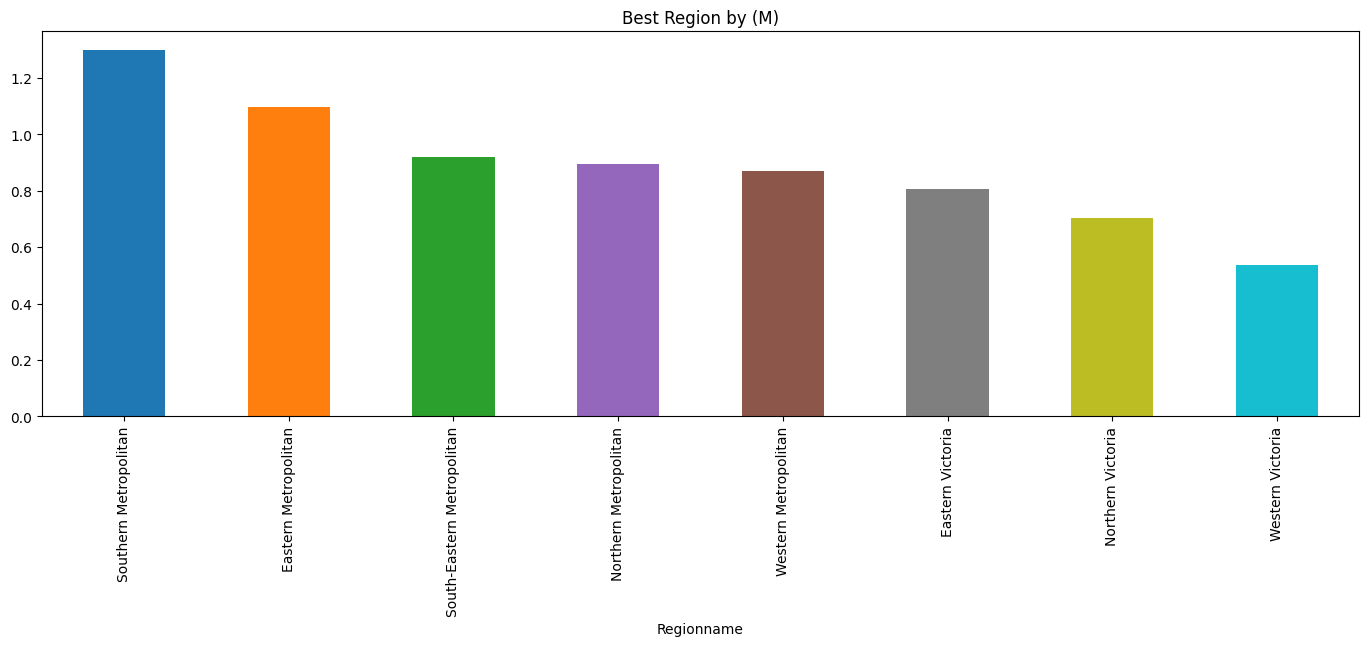

In [148]:
import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 1, len(top_region_price)))
plt.figure(figsize=(17,5))
plt.title("Best Region by (M)")
top_region_price.plot.bar(color=colors)
plt.show()

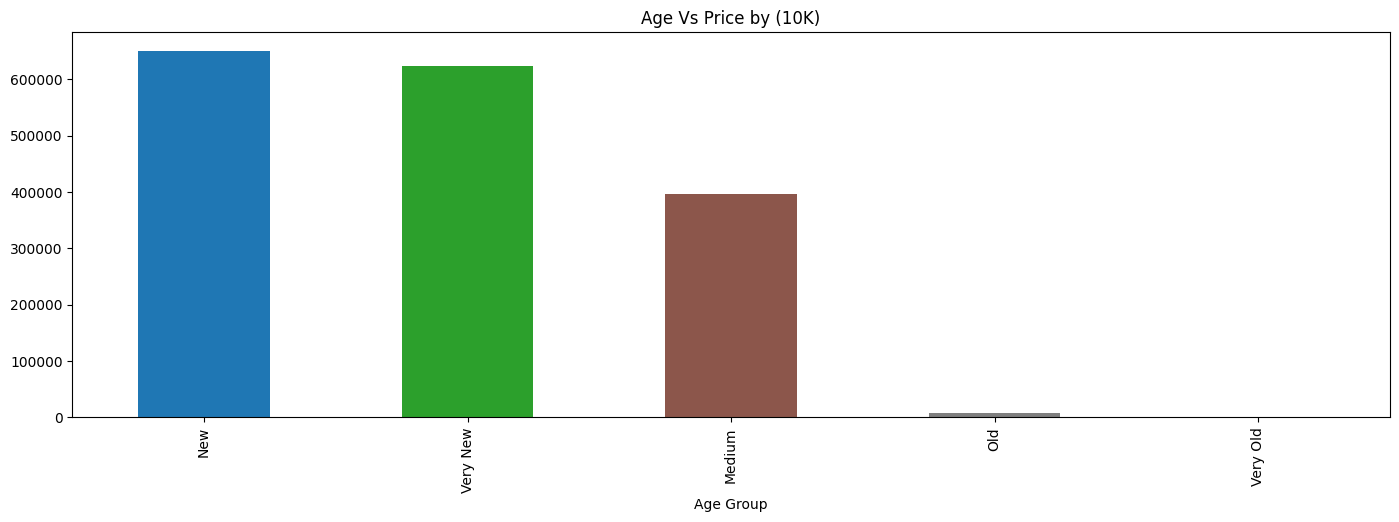

In [168]:
colors = cm.tab10(np.linspace(0, 1, len(age_vs_price)))
plt.figure(figsize=(17,5))
plt.title("Age Vs Price by (10K)")
age_vs_price.plot.bar(color=colors)
plt.show()